In [93]:
import os
import itertools
import numpy as np
import math
import matplotlib.pyplot as plt
import time


# Chọn bản đồ + hàm trực quan bản đồ

In [94]:
# ===== Nạp bản đồ =====
# Ưu tiên dùng file local của bạn, sau đó fallback sang file cùng thư mục notebook hoặc /mnt/data.
grid30 = np.loadtxt('E:\last_dance\Last-dance\map\warehouse3.txt', dtype=np.int8)

# ===== Khai báo waypoint bắt buộc =====
# Các ô trong danh sách goals sẽ được đánh dấu bằng giá trị 2 trên grid.
#goals = [(4, 6), (4, 15), (16, 4), (12, 14), (20, 20), (20, 14), (23, 17), (17, 15)]
# goals = [(4, 6), (12, 14), (18, 10)]
#goals = [(46, 46), (6, 18), (23, 37), (6, 48), (24, 6), (34, 20), (28, 46), (16, 13), (38, 44), (45, 34)]


# for goal in goals:
#     grid30[goal] = 2

grid = grid30
n = grid.shape[0]

In [95]:
import matplotlib.pyplot as plt
import numpy as np
def visualize_path(grid, path, mandatory_waypoints):
    if path:
        print("\nĐường đi được trích xuất:")
        print(path)
        L_q = path_length(path)
        print("Độ dài đường đi:", round(L_q, 3))

        # Trực quan hóa đường đi Q-Learning
        print("\nĐang trực quan hóa đường đi Q-Learning...")
        fig, ax = plt.subplots(figsize=(8, 8))

        # Vẽ bản đồ (0=free, 1=obstacle)
        # Sử dụng origin="upper" để đặt (0,0) ở góc trên bên trái
        im = ax.imshow(grid, origin="upper", interpolation="nearest", cmap="viridis")

        # Vẽ đường đi theo từng bước
        xs = [p[1] for p in path] # Hoán đổi x và y để vẽ
        ys = [p[0] for p in path] # Hoán đổi x và y để vẽ
        ax.plot(xs, ys, linewidth=2, color="red", zorder=3) # Sử dụng màu khác cho đường đi Q
        ax.scatter([path[0][1], path[-1][1]], # Hoán đổi x và y để vẽ
                [path[0][0], path[-1][0]], # Hoán đổi x và y để vẽ
                marker='x', s=160, linewidths=2.5, color="red", zorder=4)

        # Vẽ các điểm bắt buộc
        mandatory_wp_x = [wp[1] for wp in mandatory_waypoints]
        mandatory_wp_y = [wp[0] for wp in mandatory_waypoints]
        ax.scatter(mandatory_wp_x, mandatory_wp_y, marker='o', s=100, linewidths=2.5, color="blue", zorder=5, label="Điểm bắt buộc")

        # ======= THÊM LƯỚI Ô NGUYÊN  =======
        n, m = grid.shape
        ax.set_xlim(-0.5, m - 0.5) # Điều chỉnh giới hạn dựa trên lưới không xoay
        ax.set_ylim(n - 0.5, -0.5) # Điều chỉnh giới hạn và đảo ngược cho origin="upper"
        ax.set_aspect('equal')
        ax.set_xticks(np.arange(-0.5, m, 1), minor=False) # Điều chỉnh vạch đánh dấu
        ax.set_yticks(np.arange(-0.5, n, 1), minor=False) # Điều chỉnh vạch đánh dấu
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6, color='white')

        ax.set_title(f"Đường đi có độ dài={L_q:.2f}, số bước={len(path)-1}")
        ax.legend()

        plt.tight_layout()
        # out_path_q = "/mnt/data/q_learning_path.png"
        # plt.savefig(out_path_q, dpi=180)
        plt.show() # Hiển thị biểu đồ đường đi Q-Learning
        # plt.close(fig)
        # print("\nĐã lưu trực quan hóa đường đi Q-Learning vào:", out_path_q)

    else:
        print("\nKhông thể trích xuất đường đi hợp lệ từ bảng Q.")

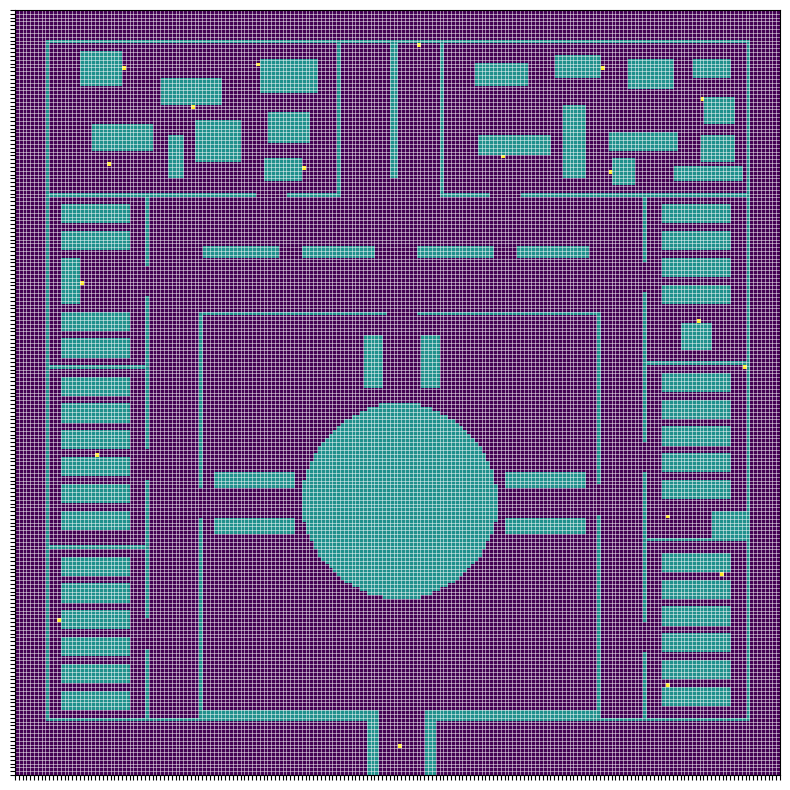

In [96]:
import matplotlib.pyplot as plt
import numpy as np

# Trực quan hóa đường đi Q-Learning
fig, ax = plt.subplots(figsize=(8, 8))

# Vẽ bản đồ (0=free, 1=obstacle)
# Sử dụng origin="upper" để đặt (0,0) ở góc trên bên trái
im = ax.imshow(grid, origin="upper", interpolation="nearest", cmap="viridis")

# ======= THÊM LƯỚI Ô NGUYÊN  =======
n, m = grid.shape
ax.set_xlim(-0.5, m - 0.5) # Điều chỉnh giới hạn dựa trên lưới không xoay
ax.set_ylim(n - 0.5, -0.5) # Điều chỉnh giới hạn và đảo ngược cho origin="upper"
ax.set_aspect('equal')
ax.set_xticks(np.arange(-0.5, m, 1), minor=False) # Điều chỉnh vạch đánh dấu
ax.set_yticks(np.arange(-0.5, n, 1), minor=False) # Điều chỉnh vạch đánh dấu
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6, color='white')


plt.tight_layout()
# out_path_q = "/mnt/data/q_learning_path.png"
# plt.savefig(out_path_q, dpi=180)
plt.show() # Hiển thị biểu đồ đường đi Q-Learning
# plt.close(fig)
# print("\nĐã lưu trực quan hóa đường đi Q-Learning vào:", out_path_q)

# Các hàm phụ trợ

In [97]:
# Kiểm tra điểm có nằm trong lưới không
def in_bounds(p, n, m):
    return 0 <= p[0] < n and 0 <= p[1] < m

# ---------- helpers ----------
MOVES8 = [(-1,-1), (-1,0), (-1,1),
          ( 0,-1),          ( 0,1),
          ( 1,-1), ( 1,0),  ( 1,1)]

# Hàm khoảng cách Euclid giữa hai điểm
def euclid(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

# Tính độ dài đường đi
def path_length(path):
    if not path or len(path) < 2:
        return 0.0
    return sum(euclid(path[i], path[i + 1]) for i in range(len(path) - 1))

In [98]:
FOUR_NEIGHBORS = [(-1,0), (1,0), (0,-1), (0,1)]
EIGHT_NEIGHBORS = [(-1,-1), (-1,0), (-1,1),
                   ( 0,-1),          ( 0,1),
                   ( 1,-1), ( 1,0),  ( 1,1)]

def is_free_cell(grid_map, cell, obstacle_value=1):
    n_rows, n_cols = grid_map.shape
    r, c = cell
    return 0 <= r < n_rows and 0 <= c < n_cols and grid_map[r][c] != obstacle_value


def has_clearance(grid_map, cell, obstacle_value=1, clearance_mode=0):
    """
    clearance_mode:
        0 : không xét vùng đệm
        4 : xét 4 ô xung quanh
        8 : xét 8 ô xung quanh
    """
    if not is_free_cell(grid_map, cell, obstacle_value):
        return False

    if clearance_mode == 0:
        return True

    dirs = FOUR_NEIGHBORS if clearance_mode == 4 else EIGHT_NEIGHBORS
    r, c = cell
    n_rows, n_cols = grid_map.shape

    for dr, dc in dirs:
        rr, cc = r + dr, c + dc
        if 0 <= rr < n_rows and 0 <= cc < n_cols:
            if grid_map[rr][cc] == obstacle_value:
                return False
    return True


def can_move_8dir_strict(grid_map, current_node, neighbor_node, obstacle_value=1, clearance_mode=0):
    """
    Kiểm tra một bước đi current_node -> neighbor_node có hợp lệ hay không:
    - neighbor phải free
    - nếu đi chéo thì không được cắt góc tường
    - có thể thêm clearance 4 hoặc 8 ô xung quanh
    """
    if not has_clearance(grid_map, neighbor_node, obstacle_value, clearance_mode):
        return False

    r0, c0 = current_node
    r1, c1 = neighbor_node
    dr = r1 - r0
    dc = c1 - c0

    # chỉ cho bước 8 hướng đúng 1 ô
    if abs(dr) > 1 or abs(dc) > 1 or (dr == 0 and dc == 0):
        return False

    # nếu đi chéo thì cấm xuyên góc
    if abs(dr) == 1 and abs(dc) == 1:
        side1 = (r0 + dr, c0)   # ô đứng theo hàng
        side2 = (r0, c0 + dc)   # ô đứng theo cột

        # 2 ô cạnh phải free
        if not is_free_cell(grid_map, side1, obstacle_value):
            return False
        if not is_free_cell(grid_map, side2, obstacle_value):
            return False

        # nếu muốn khắt khe hơn, cả 2 ô cạnh cũng phải có clearance
        if clearance_mode != 0:
            if not has_clearance(grid_map, side1, obstacle_value, clearance_mode):
                return False
            if not has_clearance(grid_map, side2, obstacle_value, clearance_mode):
                return False

    return True

In [99]:
# Tạo sub_grid từ start_point đến end_point
def create_sub_grid(start_point, end_point, grid):
    x_min = min(start_point[0], end_point[0])
    x_max = max(start_point[0], end_point[0])
    y_min = min(start_point[1], end_point[1])
    y_max = max(start_point[1], end_point[1])
    
    return grid[x_min:x_max+1, y_min:y_max+1]

In [100]:
# Tạo sub_grid từ start_point đến end_point bổ sung padding 1 ô xung quanh để tránh lỗi index khi đi chéo
#def create_sub_grid_with_padding(start_point, end_point, grid, padding):
#    x_min = min(start_point[0], end_point[0])
#    x_max = max(start_point[0], end_point[0])
#    y_min = min(start_point[1], end_point[1])
#    y_max = max(start_point[1], end_point[1])
#    
#    return grid[x_min-padding:x_max+1+padding, y_min-padding:y_max+1+padding]

def create_sub_grid_with_padding(start_point, end_point, grid, padding):
    n_rows, n_cols = grid.shape
    x0 = max(0, min(start_point[0], end_point[0]) - padding)
    x1 = min(n_rows - 1, max(start_point[0], end_point[0]) + padding)
    y0 = max(0, min(start_point[1], end_point[1]) - padding)
    y1 = min(n_cols - 1, max(start_point[1], end_point[1]) + padding)
    return grid[x0:x1+1, y0:y1+1], x0, y0

In [101]:
#test create_sub_grid
start_point = (4, 6)
end_point = (12, 14)
sub_grid = create_sub_grid(start_point, end_point, grid)
print("Sub-grid:")
print(sub_grid)

Sub-grid:
[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 1 1 1]
 [0 0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0]]


In [102]:
#test create_sub_grid_with_padding
start_point = (4, 6)
end_point = (12, 14)
padding = 1
sub_grid = create_sub_grid_with_padding(start_point, end_point, grid, padding)
print("Sub-grid với padding:")
print(sub_grid)

Sub-grid với padding:
(array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]], dtype=int8), 3, 5)


# Dijkstra + vét cạn toàn bộ thứ tự waypoint


In [103]:
# Tìm đường đi ngắn nhất từ start_point đến end_point chỉ đi xuống và sang phải (có thể đi chéo phải)
def find_path_segment_down_right(start_point, end_point, grid):
    sub_grid = create_sub_grid(start_point, end_point, grid)
    n, m = sub_grid.shape

    # B1: tính ma trận khoảng cách d
    d = np.full((n, m), fill_value=1e10, dtype=np.float64)
    d[0][0] = 0

    for i in range(1, n):
        if sub_grid[i][0] != 1:
            d[i][0] = min(d[i][0], d[i-1][0] + 1)

    for j in range(1, m):
        if sub_grid[0][j] != 1:
            d[0][j] = min(d[0][j], d[0][j-1] + 1)

    for i in range(1, n):
        for j in range(1, m):
            if sub_grid[i][j] != 1:
                d[i][j] = min(
                    d[i][j],
                    d[i-1][j] + 1,          # đi xuống
                    d[i][j-1] + 1,          # đi sang phải
                    d[i-1][j-1] + math.sqrt(2)  # đi chéo
                )

    print("Độ dài đường đi ngắn nhất tới đích:", d[n-1][m-1])

    # B2: truy vết đường đi từ (n-1, m-1) về (0,0)
    path = []
    i, j = n-1, m-1

    if d[i, j] > 1e9:
        print("Không có đường đi hợp lệ tới đích")
        return [], 1e10
    else:
        while not (i == 0 and j == 0):
            path.append((i, j))
            found = False
            # Thử lần lượt: chéo, lên, trái (ưu tiên chéo cho đẹp)
            for di, dj, cost in [(-1, -1, math.sqrt(2)), (-1, 0, 1), (0, -1, 1)]:
                pi, pj = i + di, j + dj
                if pi < 0 or pj < 0:
                    continue
                # kiểm tra xem (pi,pj) có thể là cha của (i,j) không
                if abs(d[i, j] - (d[pi, pj] + cost)) < 1e-6:
                    i, j = pi, pj
                    found = True
                    break
            if not found:
                raise RuntimeError(f"Backtrack bị kẹt tại ô {(i, j)}")

        path.append((0, 0))
        path.reverse()
        # Cộng thêm offset để chuyển từ sub_grid về grid gốc
        offset_x = min(start_point[0], end_point[0])
        offset_y = min(start_point[1], end_point[1])
        path = [(x + offset_x, y + offset_y) for x, y in path]

        return path, d[n-1][m-1]

In [104]:
def find_path_segment_down_left(start_point, end_point, grid):
    sub_grid = create_sub_grid(start_point, end_point, grid)
    n, m = sub_grid.shape

    # B1: tính ma trận khoảng cách d
    d = np.full((n, m), fill_value=1e10, dtype=np.float64)
    d[0][m-1] = 0

    for i in range(1, n):
        if sub_grid[i][m-1] != 1:
            d[i][m-1] = min(d[i][m-1], d[i-1][m-1] + 1)

    for j in range(m-2, -1, -1):
        if sub_grid[0][j] != 1:
            d[0][j] = min(d[0][j], d[0][j+1] + 1)

    for i in range(1, n):
        for j in range(m-2, -1, -1):
            if sub_grid[i][j] != 1:
                d[i][j] = min(
                    d[i][j],
                    d[i-1][j] + 1,          # đi xuống
                    d[i][j+1] + 1,          # đi sang trái
                    d[i-1][j+1] + math.sqrt(2)  # đi chéo
                )

    print("Độ dài đường đi ngắn nhất tới đích:", d[n-1][0])

    # B2: truy vết đường đi từ (n-1, 0) về (0,m-1)
    path = []
    i, j = n-1, 0

    if d[i, j] > 1e9:
        print("Không có đường đi hợp lệ tới đích")
        return [], 1e10
    else:
        while not (i == 0 and j == m-1):
            path.append((i, j))
            found = False
            # Thử lần lượt: chéo, lên, phải (ưu tiên chéo cho đẹp)
            for di, dj, cost in [(-1, 1, math.sqrt(2)), (-1, 0, 1), (0, 1, 1)]:
                pi, pj = i + di, j + dj
                if pi < 0 or pj >= m:
                    continue
                # kiểm tra xem (pi,pj) có thể là cha của (i,j) không
                if abs(d[i, j] - (d[pi, pj] + cost)) < 1e-6:
                    i, j = pi, pj
                    found = True
                    break
            if not found:
                raise RuntimeError(f"Backtrack bị kẹt tại ô {(i, j)}")

        path.append((0, m-1))
        path.reverse()
        # Cộng thêm offset để chuyển từ sub_grid về grid gốc
        offset_x = min(start_point[0], end_point[0])
        offset_y = min(start_point[1], end_point[1])
        path = [(x + offset_x, y + offset_y) for x, y in path]
        return path, d[n-1][0]

In [105]:
import heapq

# Hàm tìm đường đi ngắn nhất giữa hai điểm (start_point) và (end_point) sử dụng Dijkstra
# Với khả năng di chuyển 8 hướng và tránh chướng ngại vật (giá trị 1)
# Độ phức tạp: O(n*m*log(n*m)) trong trường hợp xấu nhất, với n và m là số hàng và số cột của lưới
def dijkstra(grid_map, start_point, end_point):
    n_rows, n_cols = grid_map.shape

    # Kiểm tra điểm bắt đầu và kết thúc có hợp lệ không
    if not in_bounds(start_point, n_rows, n_cols) or grid_map[start_point[0]][start_point[1]] == 1:
        print(f"Điểm bắt đầu {start_point} không hợp lệ hoặc là chướng ngại vật.")
        return [], 1e10 # Trả về đường đi rỗng và độ dài vô cùng lớn nếu điểm bắt đầu không hợp lệ
    if not in_bounds(end_point, n_rows, n_cols) or grid_map[end_point[0]][end_point[1]] == 1:
        print(f"Điểm kết thúc {end_point} không hợp lệ hoặc là chướng ngại vật.")
        return [], 1e10

    # distances lưu trữ khoảng cách ngắn nhất từ start_point đến mỗi ô
    # dictionary (row, col) -> min distance giữa start_point và (row, col), kích thước n_rows x n_cols
    distances = { (r, c): 1e10 for r in range(n_rows) for c in range(n_cols) } 
    distances[start_point] = 0

    # predecessors lưu trữ ô trước đó trong đường đi ngắn nhất, dạng dictionary (row, col) -> (prev_row, prev_col)
    predecessors = {}

    # priority_queue (min-heap) để lưu trữ (khoảng_cách, ô_hiện_tại), trong đó khoảng cách là khoảng cách ngắn nhất đã biết từ start_point đến ô_hiện_tại
    priority_queue = [ (0, start_point) ]

    while priority_queue: # Trong khi hàng đợi ưu tiên không rỗng
        current_distance, current_node = heapq.heappop(priority_queue) # Lấy ô có khoảng cách nhỏ nhất từ hàng đợi
        # print(f"Đang xử lý node {current_node} với khoảng cách {current_distance}")
        # print(f"Hàng đợi ưu tiên: {priority_queue}")

        # Nếu đã tìm thấy đường đi ngắn nhất đến current_node rồi, bỏ qua
        if current_distance > distances[current_node]:
            continue

        # Nếu đã đến đích, dừng tìm kiếm
        if current_node == end_point:
            break

        # Duyệt qua 8 ô lân cận
        for dr, dc in MOVES8:
            neighbor_node = (current_node[0] + dr, current_node[1] + dc)

            # Kiểm tra ô lân cận có hợp lệ không (trong biên, không phải chướng ngại vật)
            if in_bounds(neighbor_node, n_rows, n_cols) and grid_map[neighbor_node[0]][neighbor_node[1]] != 1:
                # Tính chi phí di chuyển (1 cho ngang/dọc, sqrt(2) cho chéo)
                move_cost = math.hypot(dr, dc) # math.hypot((dr, dc)) will be 1 or sqrt(2)

                # Tính khoảng cách mới đến ô lân cận
                new_distance = current_distance + move_cost

                # Nếu tìm thấy đường đi ngắn hơn đến ô lân cận
                if new_distance < distances[neighbor_node]:
                    distances[neighbor_node] = new_distance
                    # print(distances)
                    predecessors[neighbor_node] = current_node
                    # print(predecessors)
                    heapq.heappush(priority_queue, (new_distance, neighbor_node))
        
        # for dr, dc in MOVES8:
        #     neighbor_node = (current_node[0] + dr, current_node[1] + dc)

        #     # clearance_mode:
        #     #   0 = chỉ chống đi vào vật cản
        #     #   4 = xét 4 ô xung quanh
        #     #   8 = xét 8 ô xung quanh
        #     if can_move_8dir_strict(
        #         grid_map,
        #         current_node,
        #         neighbor_node,
        #         obstacle_value=1,
        #         clearance_mode=8   # đổi thành 4 nếu bạn chỉ muốn xét 4 ô
        #     ):
        #         move_cost = math.hypot(dr, dc)
        #         new_distance = current_distance + move_cost

        #         if new_distance < distances[neighbor_node]:
        #             distances[neighbor_node] = new_distance
        #             predecessors[neighbor_node] = current_node
        #             heapq.heappush(priority_queue, (new_distance, neighbor_node))

    # Tái tạo đường đi từ end_point về start_point
    path = []
    if distances[end_point] == 1e10: # Không tìm thấy đường đi
        return [], 1e10

    current = end_point
    while current != start_point:
        path.append(current)
        current = predecessors.get(current)
        if current is None: # Lỗi: không thể truy vết về điểm bắt đầu
            return [], 1e10
    path.append(start_point)
    path.reverse()

    return path, distances[end_point]

In [106]:
# def find_path_segment_with_dijkstra(start_point, end_point, grid, padding):
#     sub_grid = create_sub_grid_with_padding(start_point, end_point, grid, padding)
#     # down, right
#     if start_point[0] <= end_point[0] and start_point[1] <= end_point[1]:
#         path, dist = dijkstra(sub_grid, (padding, padding), (sub_grid.shape[0]-1-padding, sub_grid.shape[1]-1-padding))
#     elif start_point[0] <= end_point[0] and start_point[1] > end_point[1]: # down, left
#         path, dist = dijkstra(sub_grid, (padding, sub_grid.shape[1]-1-padding), (sub_grid.shape[0]-1-padding, padding))
#     elif start_point[0] > end_point[0] and start_point[1] <= end_point[1]: # up, right
#         path, dist = dijkstra(sub_grid, (sub_grid.shape[0]-1-padding, padding), (padding, sub_grid.shape[1]-1-padding))
#     else: # up, left
#         path, dist = dijkstra(sub_grid, (sub_grid.shape[0]-1-padding, sub_grid.shape[1]-1-padding), (padding, padding))
    
#     # Cộng thêm offset để chuyển từ sub_grid về grid gốc
#     offset_x = min(start_point[0], end_point[0]) - padding
#     offset_y = min(start_point[1], end_point[1]) - padding
#     path = [(x + offset_x, y + offset_y) for x, y in path]
    
#     return path, dist

In [107]:
def find_path_segment_with_dijkstra(start_point, end_point, grid, padding):
    sub_grid, x0, y0 = create_sub_grid_with_padding(start_point, end_point, grid, padding)
    local_start = (start_point[0] - x0, start_point[1] - y0)
    local_end = (end_point[0] - x0, end_point[1] - y0)
    path, dist = dijkstra(sub_grid, local_start, local_end)
    path = [(r + x0, c + y0) for r, c in path]
    return path, dist

In [108]:
# test find_path_segment_with_dijkstra
start_point = (4, 6)
end_point = (4, 15)
padding = 1
path, dist = find_path_segment_with_dijkstra(start_point, end_point, grid, padding)
print("Đường đi tìm được bởi Dijkstra:")
print(path)
print("Độ dài đường đi:", dist)

Đường đi tìm được bởi Dijkstra:
[(4, 6), (4, 7), (4, 8), (4, 9), (4, 10), (4, 11), (4, 12), (4, 13), (4, 14), (4, 15)]
Độ dài đường đi: 9.0


In [109]:
import random
from math import inf

INF = 1e10


def reverse_path(path):
    return list(reversed(path)) if path else []


def merge_segments(segments):
    total_path = []
    for i, segment in enumerate(segments):
        if not segment:
            return []
        if i == 0:
            total_path.extend(segment)
        else:
            total_path.extend(segment[1:])
    return total_path

def build_pairwise_shortest_paths(grid_map, points, verbose=True):
    """
    Tính trước đường đi ngắn nhất giữa mọi cặp điểm trong danh sách points.
    Vì chi phí di chuyển đối xứng, chỉ cần chạy Dijkstra cho mỗi cặp 1 lần.
    """
    pairwise_cache = {}

    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            a = points[i]
            b = points[j]

            path_ab, dist_ab = find_path_segment_with_dijkstra(a, b, grid_map, padding=0)
            pad = 1
            while dist_ab > 1e9 and pad <= 200:
                path_ab, dist_ab = find_path_segment_with_dijkstra(a, b, grid_map, padding=pad)
                pad += 1

            pairwise_cache[(a, b)] = (path_ab, dist_ab)

            if path_ab:
                pairwise_cache[(b, a)] = (reverse_path(path_ab), dist_ab)
            else:
                pairwise_cache[(b, a)] = ([], INF)

            if verbose:
                if dist_ab >= INF:
                    print(f'Không có đường đi giữa {a} và {b}')
                else:
                    print(f'Dijkstra({a} -> {b}) = {dist_ab:.3f}')

    return pairwise_cache

class TSPGeneticAlgorithm:
    """
    GA cho pha 2 TSP:
    - start và end là cố định
    - gene chỉ là thứ tự đi qua các waypoint bắt buộc
    - cost của mỗi cạnh lấy từ pairwise_cache[(a, b)][1]

    Cải tiến so với bản GA cũ:
    1) Có elitism giữ lại cá thể tốt nhất.
    2) Có tournament selection ổn định hơn.
    3) Có cycle crossover cho hoán vị.
    4) Có swap mutation + inversion mutation.
    5) Có local search 2-opt nhẹ để tinh chỉnh cá thể con.
    6) Có greedy seeding để quần thể khởi tạo tốt hơn random thuần.
    """

    def __init__(
        self,
        start_node,
        end_node,
        mandatory_waypoints,
        pairwise_cache,
        population_size=80,
        generations=300,
        crossover_rate=0.90,
        mutation_rate=0.20,
        elite_size=4,
        tournament_size=4,
        local_search_rate=0.30,
        stagnation_generations=80,
        random_seed=42,
        verbose=True,
    ):
        self.start_node = start_node
        self.end_node = end_node
        self.waypoints = list(mandatory_waypoints)
        self.pairwise_cache = pairwise_cache

        self.population_size = max(10, int(population_size))
        self.generations = max(1, int(generations))
        self.crossover_rate = float(crossover_rate)
        self.mutation_rate = float(mutation_rate)
        self.elite_size = max(1, min(int(elite_size), self.population_size))
        self.tournament_size = max(2, int(tournament_size))
        self.local_search_rate = float(local_search_rate)
        self.stagnation_generations = max(5, int(stagnation_generations))
        self.verbose = verbose

        self.rng = random.Random(random_seed)
        self.n = len(self.waypoints)
        self.history = []
        self.best_cost = INF
        self.best_order = []
        self.total_evaluated = 0
        self.feasible_evaluated = 0
        self._cost_cache = {}

    # ---------- Cost ----------
    def route_cost(self, order):
        key = tuple(order)
        if key in self._cost_cache:
            return self._cost_cache[key]

        cost = 0.0
        prev = self.start_node
        for idx in order:
            nxt = self.waypoints[idx]
            seg_cost = self.pairwise_cache[(prev, nxt)][1]
            if seg_cost >= INF:
                self._cost_cache[key] = INF
                return INF
            cost += seg_cost
            prev = nxt

        seg_cost = self.pairwise_cache[(prev, self.end_node)][1]
        if seg_cost >= INF:
            self._cost_cache[key] = INF
            return INF
        cost += seg_cost

        self._cost_cache[key] = cost
        return cost

    def evaluate_population(self, population):
        scored = []
        for indiv in population:
            c = self.route_cost(indiv)
            self.total_evaluated += 1
            if c < INF:
                self.feasible_evaluated += 1
            scored.append((c, indiv[:]))
        scored.sort(key=lambda x: x[0])
        return scored

    # ---------- Initialization ----------
    def nearest_neighbor_seed(self, first_idx=None):
        remaining = set(range(self.n))
        order = []
        current_point = self.start_node

        if self.n == 0:
            return order

        if first_idx is not None and first_idx in remaining:
            order.append(first_idx)
            current_point = self.waypoints[first_idx]
            remaining.remove(first_idx)

        while remaining:
            next_idx = min(
                remaining,
                key=lambda j: self.pairwise_cache[(current_point, self.waypoints[j])][1]
            )
            order.append(next_idx)
            current_point = self.waypoints[next_idx]
            remaining.remove(next_idx)

        return order

    def initialize_population(self):
        population = []
        seen = set()

        def add_candidate(candidate):
            key = tuple(candidate)
            if key not in seen:
                population.append(candidate[:])
                seen.add(key)

        # 1) greedy seeding từ nhiều waypoint đầu khác nhau
        for idx in range(min(self.n, max(2, self.population_size // 5))):
            greedy = self.nearest_neighbor_seed(first_idx=idx)
            add_candidate(greedy)
            add_candidate(list(reversed(greedy)))

        # 2) thêm một greedy không ép first_idx
        greedy = self.nearest_neighbor_seed()
        add_candidate(greedy)
        add_candidate(list(reversed(greedy)))

        # 3) random population
        while len(population) < self.population_size:
            indiv = list(range(self.n))
            self.rng.shuffle(indiv)
            add_candidate(indiv)

        return population[:self.population_size]

    # ---------- Selection ----------
    def tournament_select(self, scored_population):
        contestants = self.rng.sample(
            scored_population,
            k=min(self.tournament_size, len(scored_population))
        )
        contestants.sort(key=lambda x: x[0])
        return contestants[0][1][:]

    # ---------- Crossover / Mutation ----------
    def cycle_crossover(self, p1, p2):
        n = len(p1)
        if n <= 1:
            return p1[:], p2[:]

        child1 = [None] * n
        child2 = [None] * n
        visited = [False] * n
        use_p1 = True

        pos_in_p1 = {v: i for i, v in enumerate(p1)}

        while not all(visited):
            start = next(i for i in range(n) if not visited[i])
            idx = start
            cycle = []

            while not visited[idx]:
                visited[idx] = True
                cycle.append(idx)
                val = p2[idx]
                idx = pos_in_p1[val]

            if use_p1:
                for i in cycle:
                    child1[i] = p1[i]
                    child2[i] = p2[i]
            else:
                for i in cycle:
                    child1[i] = p2[i]
                    child2[i] = p1[i]

            use_p1 = not use_p1

        return child1, child2

    def mutate(self, indiv):
        n = len(indiv)
        if n <= 1:
            return indiv

        child = indiv[:]

        # swap mutation
        if self.rng.random() < self.mutation_rate:
            i, j = sorted(self.rng.sample(range(n), 2))
            child[i], child[j] = child[j], child[i]

        # inversion mutation (giúp TSP tốt hơn swap đơn thuần)
        if n >= 4 and self.rng.random() < self.mutation_rate * 0.7:
            i, j = sorted(self.rng.sample(range(n), 2))
            child[i:j+1] = reversed(child[i:j+1])

        return child

    # ---------- Local search ----------
    def two_opt_once(self, order):
        if len(order) < 4:
            return order, False

        best = order[:]
        best_cost = self.route_cost(best)
        n = len(order)

        for i in range(n - 1):
            for j in range(i + 1, n):
                candidate = best[:]
                candidate[i:j+1] = reversed(candidate[i:j+1])
                cand_cost = self.route_cost(candidate)
                if cand_cost < best_cost:
                    return candidate, True

        return best, False

    def local_search(self, order, max_rounds=8):
        current = order[:]
        for _ in range(max_rounds):
            current, improved = self.two_opt_once(current)
            if not improved:
                break
        return current

    # ---------- Main solve ----------
    def solve(self):
        if self.n == 0:
            self.best_order = []
            self.best_cost = self.pairwise_cache[(self.start_node, self.end_node)][1]
            self.history = [self.best_cost]
            return [], self.best_cost

        population = self.initialize_population()
        scored = self.evaluate_population(population)

        self.best_cost = scored[0][0]
        self.best_order = scored[0][1][:]
        self.history = [self.best_cost]
        no_improve = 0

        if self.verbose:
            print(f'[GA] Generation 0 | best cost = {self.best_cost:.3f}')

        for gen in range(1, self.generations + 1):
            elites = [indiv[:] for _, indiv in scored[:self.elite_size]]
            children = []

            while len(children) < self.population_size:
                p1 = self.tournament_select(scored)
                p2 = self.tournament_select(scored)
                while p2 == p1 and len(scored) > 1:
                    p2 = self.tournament_select(scored)

                if self.rng.random() < self.crossover_rate:
                    c1, c2 = self.cycle_crossover(p1, p2)
                else:
                    c1, c2 = p1[:], p2[:]

                c1 = self.mutate(c1)
                c2 = self.mutate(c2)

                if self.rng.random() < self.local_search_rate:
                    c1 = self.local_search(c1)
                if self.rng.random() < self.local_search_rate:
                    c2 = self.local_search(c2)

                children.append(c1)
                if len(children) < self.population_size:
                    children.append(c2)

            combined = elites + children
            scored = self.evaluate_population(combined)
            scored = scored[:self.population_size]

            current_best_cost, current_best_order = scored[0][0], scored[0][1][:]
            self.history.append(current_best_cost)

            if current_best_cost < self.best_cost:
                self.best_cost = current_best_cost
                self.best_order = current_best_order
                no_improve = 0
            else:
                no_improve += 1

            if self.verbose and (gen == 1 or gen % 10 == 0 or gen == self.generations):
                print(f'[GA] Generation {gen} | best cost = {self.best_cost:.3f}')

            if no_improve >= self.stagnation_generations:
                if self.verbose:
                    print(f'[GA] Dừng sớm tại generation {gen} do không cải thiện thêm.')
                break

        best_order_points = [self.waypoints[i] for i in self.best_order]
        return best_order_points, self.best_cost


def find_shortest_path_with_mandatory_waypoints_ga(
    grid_map,
    start_node,
    end_node,
    mandatory_waypoints,
    population_size=100,
    generations=300,
    crossover_rate=0.90,
    mutation_rate=0.20,
    elite_size=4,
    tournament_size=4,
    local_search_rate=0.30,
    stagnation_generations=80,
    seed=42,
    verbose=True,
):
    """
    Thay cho hàm brute force ở pha 2 TSP.

    Trả về:
    ((best_path, best_length), best_order, total_candidates_evaluated, feasible_candidates_evaluated, ga)
    """
    mandatory_waypoints = [wp for wp in mandatory_waypoints if wp != start_node and wp != end_node]
    mandatory_waypoints = list(dict.fromkeys(mandatory_waypoints))

    if not mandatory_waypoints:
        path, dist = dijkstra(grid_map, start_node, end_node)
        dummy_ga = None
        return (path, dist), [], 1, 1 if dist < INF else 0, dummy_ga

    all_points = [start_node] + mandatory_waypoints + [end_node]
    pairwise_cache = build_pairwise_shortest_paths(grid_map, all_points, verbose=verbose)

    ga = TSPGeneticAlgorithm(
        start_node=start_node,
        end_node=end_node,
        mandatory_waypoints=mandatory_waypoints,
        pairwise_cache=pairwise_cache,
        population_size=population_size,
        generations=generations,
        crossover_rate=crossover_rate,
        mutation_rate=mutation_rate,
        elite_size=elite_size,
        tournament_size=tournament_size,
        local_search_rate=local_search_rate,
        stagnation_generations=stagnation_generations,
        random_seed=seed,
        verbose=verbose,
    )

    best_order, best_length = ga.solve()

    if best_length >= INF:
        return ([], INF), [], ga.total_evaluated, ga.feasible_evaluated, ga

    route = [start_node] + best_order + [end_node]
    segments = []
    for a, b in zip(route[:-1], route[1:]):
        seg_path, seg_cost = pairwise_cache[(a, b)]
        if seg_cost >= INF or not seg_path:
            return ([], INF), [], ga.total_evaluated, ga.feasible_evaluated, ga
        segments.append(seg_path)

    best_path = merge_segments(segments)
    return (best_path, best_length), best_order, ga.total_evaluated, ga.feasible_evaluated, ga


Start node: (9, 105)
End node: (9, 105)
Các waypoint bắt buộc: [(9, 105), (14, 63), (15, 28), (15, 153), (23, 179), (25, 46), (38, 127), (40, 24), (41, 75), (42, 155), (71, 17), (81, 178), (93, 190), (116, 21), (132, 170), (147, 184), (159, 11), (176, 170), (192, 100)]
Số waypoint bắt buộc: 19
Dijkstra((9, 105) -> (14, 63)) = 107.042
Dijkstra((9, 105) -> (15, 28)) = 128.154
Dijkstra((9, 105) -> (15, 153)) = 105.598
Dijkstra((9, 105) -> (23, 179)) = 124.770
Dijkstra((9, 105) -> (25, 46)) = 108.355
Dijkstra((9, 105) -> (38, 127)) = 67.142
Dijkstra((9, 105) -> (40, 24)) = 118.284
Dijkstra((9, 105) -> (41, 75)) = 78.627
Dijkstra((9, 105) -> (42, 155)) = 89.385
Dijkstra((9, 105) -> (71, 17)) = 130.669
Dijkstra((9, 105) -> (81, 178)) = 122.740
Dijkstra((9, 105) -> (93, 190)) = 175.610
Dijkstra((9, 105) -> (116, 21)) = 158.782
Dijkstra((9, 105) -> (132, 170)) = 156.953
Dijkstra((9, 105) -> (147, 184)) = 207.510
Dijkstra((9, 105) -> (159, 11)) = 208.409
Dijkstra((9, 105) -> (176, 170)) = 200.9

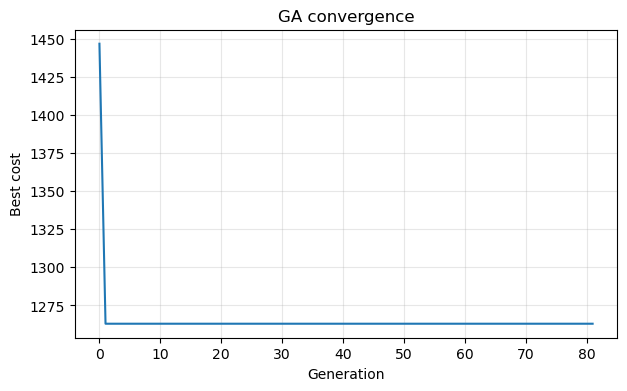

In [110]:
# --- Thực thi chính với GA cho pha 2 TSP ---
start_exec_time = time.time()

# grid[29][27] = 0
# start_node = (29, 27)
# end_node = (29, 27)

# Trích xuất các waypoint bắt buộc (giá trị 2) từ bản đồ
mandatory_waypoints = []
for r in range(n):
    for c in range(grid.shape[1]):
        if grid[r][c] == 2:
            mandatory_waypoints.append((r, c))

grid[mandatory_waypoints[0][0]][mandatory_waypoints[0][1]] = 0
start_node = (mandatory_waypoints[0][0], mandatory_waypoints[0][1])
end_node = (mandatory_waypoints[0][0], mandatory_waypoints[0][1])

# mandatory_waypoints = [wp for wp in mandatory_waypoints if wp != start_node and wp != end_node]
mandatory_waypoints = list(dict.fromkeys(mandatory_waypoints))

print(f'Start node: {start_node}')
print(f'End node: {end_node}')
print(f'Các waypoint bắt buộc: {mandatory_waypoints}')
print(f'Số waypoint bắt buộc: {len(mandatory_waypoints)}')

if not mandatory_waypoints:
    print('Không có waypoint bắt buộc. Chạy Dijkstra trực tiếp từ start đến end...')
    path, L_q = dijkstra(grid, start_node, end_node)
    best_order = []
    total_candidates = 1
    feasible_candidates = 1 if L_q < INF else 0
    ga = None
else:
    (path, L_q), best_order, total_candidates, feasible_candidates, ga = find_shortest_path_with_mandatory_waypoints_ga(
        grid_map=grid,
        start_node=start_node,
        end_node=end_node,
        mandatory_waypoints=mandatory_waypoints,
        population_size=100,
        generations=500,
        crossover_rate=0.90,
        mutation_rate=0.20,
        elite_size=4,
        tournament_size=4,
        local_search_rate=0.30,
        stagnation_generations=80,
        seed=42,
        verbose=True,
    )

end_exec_time = time.time()

print() 
print('===== KẾT QUẢ =====')
print(f'Tổng số cá thể đã đánh giá bởi GA: {total_candidates}')
print(f'Số cá thể hợp lệ đã gặp: {feasible_candidates}')

if L_q >= INF:
    print('Không tìm thấy đường đi hợp lệ đi qua tất cả waypoint bắt buộc.')
else:
    print(f'Thứ tự waypoint tốt nhất GA tìm được: {best_order}')
    print(f'Độ dài đường đi tốt nhất: {L_q:.3f}')
    print('Đường đi (theo thứ tự các ô):')
    for cell in path:
        print(cell)

print(f'Thời gian chạy: {end_exec_time - start_exec_time:.6f} giây')

if ga is not None:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7, 4))
    plt.plot(ga.history)
    plt.xlabel('Generation')
    plt.ylabel('Best cost')
    plt.title('GA convergence')
    plt.grid(True, alpha=0.3)
    plt.show()



Đường đi được trích xuất:
[(9, 105), (10, 104), (11, 103), (12, 102), (13, 101), (14, 100), (15, 100), (16, 100), (17, 100), (18, 100), (19, 100), (20, 100), (21, 100), (22, 100), (23, 100), (24, 100), (25, 100), (26, 100), (27, 100), (28, 100), (29, 100), (30, 100), (31, 100), (32, 100), (33, 100), (34, 100), (35, 100), (36, 100), (37, 100), (38, 100), (39, 100), (40, 100), (41, 100), (42, 100), (43, 100), (44, 99), (45, 98), (46, 97), (47, 96), (48, 95), (49, 94), (49, 93), (49, 92), (49, 91), (49, 90), (49, 89), (49, 88), (49, 87), (49, 86), (49, 85), (49, 84), (49, 83), (49, 82), (49, 81), (49, 80), (49, 79), (49, 78), (49, 77), (49, 76), (49, 75), (49, 74), (49, 73), (49, 72), (49, 71), (48, 70), (47, 71), (47, 72), (46, 73), (45, 74), (44, 75), (43, 75), (42, 75), (41, 75), (40, 75), (39, 75), (38, 74), (37, 73), (36, 72), (35, 71), (35, 70), (35, 69), (35, 68), (35, 67), (35, 66), (34, 65), (33, 64), (32, 63), (31, 63), (30, 63), (29, 63), (28, 63), (27, 63), (26, 63), (25, 63)

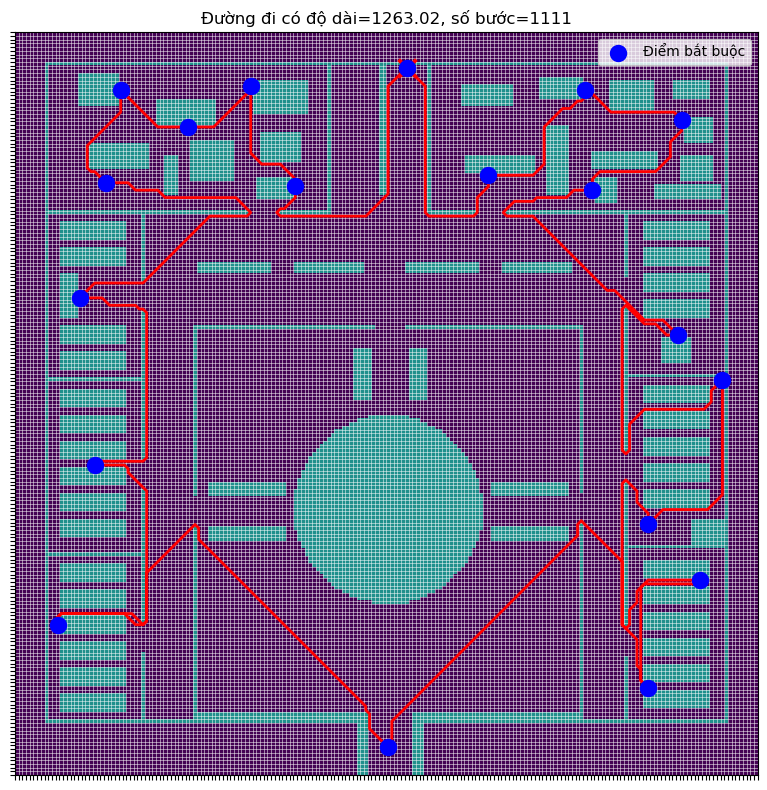

In [111]:
visualize_path(grid, path, mandatory_waypoints)

# Làm mượt đường đi theo đúng Hình 2 của bài báo

Ở Hình 2, phần làm mượt **không ép robot đi lại theo đường gấp khúc cũ**. Ý đúng là:

1. Từ `path` gốc, chỉ giữ lại **start**, **goal**, **các inflection point**, và **mandatory waypoints**.  
2. Xét từng bộ ba điểm liên tiếp `A, B, C` trong danh sách key points.  
3. Nếu có thể **nối thẳng trực tiếp** `A -> C` mà không xuyên qua obstacle thì bỏ `B` (trừ khi `B` là waypoint bắt buộc).  
4. Path sau cùng được hiểu là một **polyline** đi qua các key points còn lại; mỗi đoạn giữa hai key points liên tiếp là **một đoạn thẳng**.

Để kiểm tra điều kiện “không có vật cản nằm giữa đường thẳng”, bên dưới dùng **supercover line-of-sight**.  
Lưu ý: danh sách `smoothed_vertices` là **các đỉnh của polyline sau làm mượt**. Nếu cần một danh sách ô lưới để debug/hiển thị, notebook vẫn tạo thêm `smoothed_path_cells`.


In [ ]:
# ===== Hậu xử lý làm mượt đường đi theo đúng Hình 2 của bài báo =====

def remove_consecutive_duplicates(path):
    """
    Xóa các phần tử trùng nhau liên tiếp trong path
    """
    if not path:
        return []
    compact = [path[0]]
    for pt in path[1:]:
        if pt != compact[-1]:
            compact.append(pt)
    return compact


def extract_inflection_points(path, mandatory_waypoints, keep_start_goal=True):
    """
    Bước 2 của bài báo:
    giữ lại start, goal, các inflection point và các mandatory waypoint.
    """
    path = remove_consecutive_duplicates(path)
    if not path:
        return []

    mandatory_set = set(mandatory_waypoints)
    selected = []
    seen = set()

    for i, pt in enumerate(path):
        keep = False

        if keep_start_goal and (i == 0 or i == len(path) - 1):
            keep = True

        if pt in mandatory_set:
            keep = True

        if 0 < i < len(path) - 1:
            v1 = (path[i][0] - path[i - 1][0], path[i][1] - path[i - 1][1])
            v2 = (path[i + 1][0] - path[i][0], path[i + 1][1] - path[i][1])

            # đổi hướng => inflection point
            if v1 != v2:
                keep = True

        if keep and pt not in seen:
            selected.append(pt)
            seen.add(pt)

    return selected


import math

def supercover_line(a, b):
    """
    Trả về tất cả ô mà đoạn thẳng nối tâm ô a -> tâm ô b đi qua hoặc chạm vào.
    Point có dạng (row, col).
    """
    r0, c0 = a
    r1, c1 = b

    x0, y0 = c0 + 0.5, r0 + 0.5
    x1, y1 = c1 + 0.5, r1 + 0.5

    dx = x1 - x0
    dy = y1 - y0

    cells = {(r0, c0), (r1, c1)}

    steps = int(max(abs(dx), abs(dy)) * 20) + 1

    for k in range(steps + 1):
        t = k / steps
        x = x0 + dx * t
        y = y0 + dy * t

        c = int(math.floor(x))
        r = int(math.floor(y))
        cells.add((r, c))

        eps = 1e-9
        fx = x - math.floor(x)
        fy = y - math.floor(y)

        # nếu đoạn đi đúng trên biên ô thì thêm cả ô kề
        if abs(fx) < eps:
            cells.add((r, c - 1))
        if abs(fy) < eps:
            cells.add((r - 1, c))
        if abs(fx) < eps and abs(fy) < eps:
            cells.add((r - 1, c - 1))

    def proj(cell):
        rr, cc = cell
        cx, cy = cc + 0.5, rr + 0.5
        if abs(dx) >= abs(dy):
            return (cx - x0) / (dx if abs(dx) > 1e-12 else 1.0)
        return (cy - y0) / (dy if abs(dy) > 1e-12 else 1.0)

    cells = [p for p in cells if isinstance(p[0], int) and isinstance(p[1], int)]
    return sorted(cells, key=proj)


# def has_line_of_sight_strict(grid_map, a, b, obstacle_value=1):
#     """
#     Đoạn a -> b chỉ hợp lệ nếu không chạm bất kỳ ô obstacle nào.
#     """
#     n_rows, n_cols = grid_map.shape
#     for r, c in supercover_line(a, b):
#         if not (0 <= r < n_rows and 0 <= c < n_cols):
#             return False
#         if grid_map[r][c] == obstacle_value:
#             return False
#     return True

def has_line_of_sight_strict(grid_map, a, b, obstacle_value=1, clearance_mode=8):
    """
    Đoạn a -> b hợp lệ nếu:
    - không đi qua ô obstacle
    - mỗi ô trên đoạn đều đạt clearance
    - nếu giữa 2 ô liên tiếp trên supercover là bước chéo, không được cắt góc tường
    """
    cells = supercover_line(a, b)

    if not cells:
        return False

    for i, cell in enumerate(cells):
        # ô trên đoạn phải an toàn
        if not has_clearance(grid_map, cell, obstacle_value, clearance_mode):
            return False

        # kiểm tra corner-cut giữa 2 ô liên tiếp trên đoạn raster
        if i > 0:
            prev = cells[i - 1]
            r0, c0 = prev
            r1, c1 = cell
            dr = r1 - r0
            dc = c1 - c0

            if abs(dr) == 1 and abs(dc) == 1:
                side1 = (r0 + dr, c0)
                side2 = (r0, c0 + dc)

                if not is_free_cell(grid_map, side1, obstacle_value):
                    return False
                if not is_free_cell(grid_map, side2, obstacle_value):
                    return False

                if clearance_mode != 0:
                    if not has_clearance(grid_map, side1, obstacle_value, clearance_mode):
                        return False
                    if not has_clearance(grid_map, side2, obstacle_value, clearance_mode):
                        return False

    return True


def rasterize_polyline(vertices):
    """
    Chỉ để hiển thị/debug: biến polyline thành danh sách ô mà nó đi qua.
    """
    if not vertices:
        return []

    cells = [vertices[0]]
    for i in range(len(vertices) - 1):
        seg = supercover_line(vertices[i], vertices[i + 1])
        if cells[-1] == seg[0]:
            cells.extend(seg[1:])
        else:
            cells.extend(seg)
    return cells


def count_turns(path_or_vertices):
    pts = remove_consecutive_duplicates(path_or_vertices)
    if len(pts) < 3:
        return 0

    turns = 0
    for i in range(1, len(pts) - 1):
        v1 = (pts[i][0] - pts[i - 1][0], pts[i][1] - pts[i - 1][1])
        v2 = (pts[i + 1][0] - pts[i][0], pts[i + 1][1] - pts[i][1])
        if v1 != v2:
            turns += 1
    return turns


def polyline_length(vertices):
    """
    Độ dài thật của path sau làm mượt:
    tổng độ dài các đoạn thẳng giữa các vertices liên tiếp.
    """
    if not vertices or len(vertices) < 2:
        return 0.0
    return sum(euclid(vertices[i], vertices[i + 1]) for i in range(len(vertices) - 1))


def smooth_key_points_by_paper(grid_map, key_points, mandatory_waypoints):
    """
    Bước 3/4 theo đúng ý Hình 2:
    - làm việc trên danh sách key points
    - xét các bộ ba A, B, C liên tiếp
    - nếu A -> C không va obstacle thì bỏ B
    - không bao giờ bỏ mandatory waypoint
    """
    if len(key_points) <= 2:
        return key_points[:]

    mandatory_set = set(mandatory_waypoints)
    pts = key_points[:]

    i = 0
    while i < len(pts) - 2:
        A = pts[i]
        B = pts[i + 1]
        C = pts[i + 2]

        can_skip_B = (
            B not in mandatory_set
            and has_line_of_sight_strict(grid_map, A, C, obstacle_value=1, clearance_mode=8)
        )

        if can_skip_B:
            del pts[i + 1]
            if i > 0:
                i -= 1
        else:
            i += 1

    return pts


def smooth_path_by_paper(grid_map, raw_path, mandatory_waypoints):
    key_points = extract_inflection_points(raw_path, mandatory_waypoints, keep_start_goal=True)
    if len(key_points) <= 2:
        return key_points, key_points[:], rasterize_polyline(key_points)

    mandatory_set = set(mandatory_waypoints)
    smoothed_vertices = key_points[:]

    i = 0
    while i < len(smoothed_vertices) - 2:
        A = smoothed_vertices[i]
        B = smoothed_vertices[i + 1]
        C = smoothed_vertices[i + 2]

        if B not in mandatory_set and has_line_of_sight_strict(grid_map, A, C):
            del smoothed_vertices[i + 1]
            if i > 0:
                i -= 1
        else:
            i += 1

    smoothed_path_cells = rasterize_polyline(smoothed_vertices)
    return key_points, smoothed_vertices, smoothed_path_cells


def visualize_smoothing_comparison(grid, raw_path, smoothed_vertices, mandatory_waypoints,
                                   key_points_before=None, key_points_after=None):
    """
    Vẽ so sánh giống tinh thần Hình 2:
    - path gốc: nét đứt đen
    - path sau làm mượt: các đoạn thẳng xanh nối trực tiếp giữa key points
    - mandatory waypoints: xanh lá
    - key points sau làm mượt: đỏ
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(grid, origin="upper", interpolation="nearest", cmap="gray_r")

    n, m = grid.shape
    ax.set_xlim(-0.5, m - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_xticks(np.arange(-0.5, m, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.8)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    if raw_path:
        xs = [p[1] for p in raw_path]
        ys = [p[0] for p in raw_path]
        ax.plot(xs, ys, "k--", linewidth=2.5, label="Path gốc")

    if smoothed_vertices:
        xs = [p[1] for p in smoothed_vertices]
        ys = [p[0] for p in smoothed_vertices]
        ax.plot(xs, ys, linewidth=3, color="#18a0e0", label="Path sau làm mượt (đoạn thẳng)")

        ax.scatter(
            [smoothed_vertices[0][1], smoothed_vertices[-1][1]],
            [smoothed_vertices[0][0], smoothed_vertices[-1][0]],
            marker="x", s=160, linewidths=2.5, color="red", zorder=5
        )

    if mandatory_waypoints:
        ax.scatter(
            [p[1] for p in mandatory_waypoints],
            [p[0] for p in mandatory_waypoints],
            marker="o", s=90, linewidths=2, edgecolors="green",
            facecolors="none", zorder=6, label="Mandatory"
        )

    if key_points_after:
        ax.scatter(
            [p[1] for p in key_points_after],
            [p[0] for p in key_points_after],
            marker="s", s=55, color="red", zorder=6, label="Vertices sau rút gọn"
        )

    ax.set_title("So sánh path gốc và polyline sau làm mượt")
    ax.legend(loc="best")
    plt.show()


In [113]:
print(extract_inflection_points(path, mandatory_waypoints, keep_start_goal=True))

[(9, 105), (14, 100), (43, 100), (49, 94), (49, 71), (48, 70), (47, 71), (47, 72), (44, 75), (41, 75), (39, 75), (35, 71), (35, 66), (32, 63), (14, 63), (15, 63), (25, 53), (25, 46), (25, 38), (15, 28), (21, 28), (30, 19), (36, 19), (37, 20), (37, 21), (40, 24), (40, 30), (42, 32), (42, 38), (44, 40), (44, 59), (48, 63), (49, 62), (49, 52), (67, 34), (67, 21), (71, 17), (71, 23), (73, 25), (73, 32), (74, 33), (74, 34), (75, 35), (114, 35), (115, 34), (115, 22), (116, 21), (116, 29), (117, 30), (118, 30), (123, 35), (158, 35), (159, 34), (159, 32), (156, 29), (156, 12), (157, 11), (159, 11), (156, 31), (145, 35), (132, 48), (133, 49), (136, 49), (181, 94), (182, 94), (183, 95), (187, 95), (192, 100), (191, 101), (185, 101), (135, 151), (132, 151), (131, 152), (142, 163), (159, 163), (163, 167), (170, 167), (171, 168), (174, 168), (176, 170), (149, 168), (147, 170), (147, 184), (148, 183), (148, 169), (150, 167), (153, 167), (155, 165), (159, 165), (160, 164), (121, 163), (120, 164), (12

In [114]:
# test supercover_line

a = (0, 0)
b = (2, 3)
cells = supercover_line(a, b)
print("Cells covered by line from", a, "to", b, ":", cells)

Cells covered by line from (0, 0) to (2, 3) : [(0, 0), (0, 1), (1, 1), (1, 2), (2, 2), (2, 3)]


===== LÀM MƯỢT ĐƯỜNG ĐI =====
Key points trước khi rút gọn (start + inflection + mandatory + goal):
[(9, 105), (14, 100), (43, 100), (49, 94), (49, 71), (48, 70), (47, 71), (47, 72), (44, 75), (41, 75), (39, 75), (35, 71), (35, 66), (32, 63), (14, 63), (15, 63), (25, 53), (25, 46), (25, 38), (15, 28), (21, 28), (30, 19), (36, 19), (37, 20), (37, 21), (40, 24), (40, 30), (42, 32), (42, 38), (44, 40), (44, 59), (48, 63), (49, 62), (49, 52), (67, 34), (67, 21), (71, 17), (71, 23), (73, 25), (73, 32), (74, 33), (74, 34), (75, 35), (114, 35), (115, 34), (115, 22), (116, 21), (116, 29), (117, 30), (118, 30), (123, 35), (158, 35), (159, 34), (159, 32), (156, 29), (156, 12), (157, 11), (159, 11), (156, 31), (145, 35), (132, 48), (133, 49), (136, 49), (181, 94), (182, 94), (183, 95), (187, 95), (192, 100), (191, 101), (185, 101), (135, 151), (132, 151), (131, 152), (142, 163), (159, 163), (163, 167), (170, 167), (171, 168), (174, 168), (176, 170), (149, 168), (147, 170), (147, 184), (148, 183),

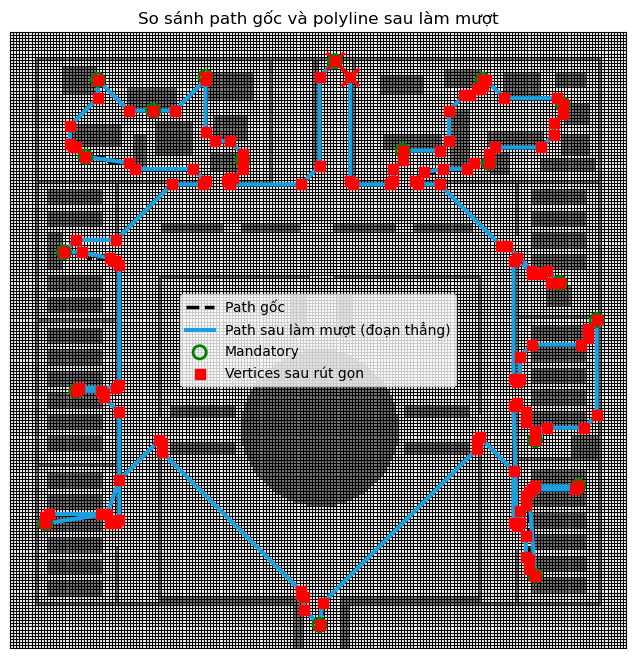

In [115]:
# ===== Chạy bước làm mượt sau khi đã có path từ Dijkstra + vét cạn =====
if path and L_q < INF:
    key_points_before, smoothed_vertices, smoothed_path_cells = smooth_path_by_paper(
        grid, path, mandatory_waypoints
    )

    L_q_smooth = polyline_length(smoothed_vertices)
    turns_before = count_turns(path)
    turns_after = count_turns(smoothed_vertices)

    print('===== LÀM MƯỢT ĐƯỜNG ĐI =====')
    print('Key points trước khi rút gọn (start + inflection + mandatory + goal):')
    print(key_points_before)
    print()
    print('Vertices sau khi rút gọn (path cuối là các đoạn thẳng nối các điểm này):')
    print(smoothed_vertices)
    print()
    print(f'Độ dài path gốc: {path_length(path):.3f}')
    print(f'Độ dài polyline sau làm mượt: {L_q_smooth:.3f}')
    print(f'Số điểm rẽ trước khi làm mượt: {turns_before}')
    print(f'Số điểm rẽ sau khi làm mượt: {turns_after}')
    print('Danh sách vertices của đường đi sau làm mượt:')
    for pt in smoothed_vertices:
        print(pt)

    print('\nDanh sách ô lưới mà polyline sau làm mượt đi qua (chỉ để debug/hiển thị):')
    for cell in smoothed_path_cells:
        print(cell)

    print('\nTrực quan hóa giống tinh thần Hình 2...')
    visualize_smoothing_comparison(
        grid,
        raw_path=path,
        smoothed_vertices=smoothed_vertices,
        mandatory_waypoints=mandatory_waypoints,
        key_points_before=key_points_before,
        key_points_after=smoothed_vertices
    )
else:
    print('Không có path hợp lệ để làm mượt.')
